## **Environment Setup & Data Loading**

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import statsmodels.api as sm
import importlib

In [2]:
sys.path.append(os.path.abspath("../"))

In [3]:
import src.scorecard_utils
import src.metrics

importlib.reload(src.scorecard_utils)
importlib.reload(src.metrics)

from src.scorecard_utils import fit_logistic_regression, iterative_p_value_elimination
from src.metrics import calculate_gini, calculate_ks

In [4]:
TRAIN_DATA_PATH = '../data/processed/train_woe_final_96.csv'
TEST_DATA_PATH = '../data/processed/test_woe_final_96.csv'

train_woe = pd.read_csv(TRAIN_DATA_PATH)
test_woe = pd.read_csv(TEST_DATA_PATH)

X_train = train_woe.drop(columns=['TARGET'])
y_train = train_woe['TARGET']

X_test = test_woe.drop(columns=['TARGET'])
y_test = test_woe['TARGET']

print(f"X_train shape: {X_train.shape} | y_train mean (Bad Rate): {y_train.mean():.4%}")
print(f"X_test shape: {X_test.shape} | y_test mean (Bad Rate): {y_test.mean():.4%}")

X_train shape: (32599, 96) | y_train mean (Bad Rate): 8.0739%
X_test shape: (92254, 96) | y_test mean (Bad Rate): 8.0734%


## **Initial Statistical Modeling (The Full Model)**

In [5]:
# Train the initial Logistic Regression model with all 96 features
full_model = fit_logistic_regression(X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.244714
         Iterations 7


In [6]:
# This summary provides P-values, Coefficients (Beta), and Model Fit statistics
print(full_model.summary())

                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                32599
Model:                          Logit   Df Residuals:                    32502
Method:                           MLE   Df Model:                           96
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1278
Time:                        18:33:23   Log-Likelihood:                -7977.4
converged:                       True   LL-Null:                       -9146.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           -2.5856      0.044    -58.351      0.000      -2.672      -2.499
EXT_SOURCE_2                 

In [7]:
# Calculate initial probabilities for the training set
y_prob_train_full = full_model.predict(sm.add_constant(X_train))

# Initial Performance Metrics
baseline_gini = calculate_gini(y_train, y_prob_train_full)
baseline_ks = calculate_ks(y_train, y_prob_train_full)

print("-" * 30)
print(f"Baseline Gini (Train): {baseline_gini:.4f}")
print(f"Baseline KS (Train)  : {baseline_ks:.4f}")

------------------------------
Baseline Gini (Train): 0.5235
Baseline KS (Train)  : 0.3878


In [8]:
stats_df = pd.DataFrame({
    'coef': full_model.params,
    'std_err': full_model.bse,
    'z_score': full_model.tvalues,
    'p_value': full_model.pvalues,
    'ci_lower': full_model.conf_int()[0],
    'ci_upper': full_model.conf_int()[1]
})

stats_df = stats_df.drop('const')

In [18]:
# 1. P-Value Clustering (Significance)
sig_count = (stats_df['p_value'] < 0.05).sum()
insig_count = (stats_df['p_value'] >= 0.05).sum()
print("P-VALUE CLUSTERING:")
print(f"Significant Features (P < 0.05): {sig_count}")
print(f"Insignificant Features (P >= 0.05): {insig_count}")

P-VALUE CLUSTERING:
Significant Features (P < 0.05): 31
Insignificant Features (P >= 0.05): 65


In [19]:
# 2. Coefficient Direction (Business Logic)
pos_coef = (stats_df['coef'] > 0).sum()
neg_coef = (stats_df['coef'] < 0).sum()
print("COEFFICIENT DIRECTION:")
print(f"Positive Coefficients (+): {pos_coef}")
print(f"Negative Coefficients (-): {neg_coef}")

COEFFICIENT DIRECTION:
Positive Coefficients (+): 20
Negative Coefficients (-): 76


In [20]:
# 3. Standard Error Spread (Model Confidence)
print("STANDARD ERROR SPREAD")
print(f"Min Error: {stats_df['std_err'].min():.4f} (Most reliable feature)")
print(f"Max Error: {stats_df['std_err'].max():.4f} (Least reliable feature)")
print(f"Mean Error: {stats_df['std_err'].mean():.4f}")

STANDARD ERROR SPREAD
Min Error: 0.0414 (Most reliable feature)
Max Error: 0.7954 (Least reliable feature)
Mean Error: 0.2627


In [21]:
# 4. Confidence Interval Check
crosses_zero = ((stats_df['ci_lower'] < 0) & (stats_df['ci_upper'] > 0)).sum()
print("CONFIDENCE INTERVAL:")
print(f"Features crossing zero (Potentially useless): {crosses_zero}")

CONFIDENCE INTERVAL:
Features crossing zero (Potentially useless): 65


In [17]:
print("\n--- TOP 30 MOST RELIABLE FEATURES ---")
top_reliable = stats_df[stats_df['p_value'] < 0.05].sort_values(by='std_err').head(30)
print(top_reliable[['coef', 'std_err', 'p_value']])


--- TOP 30 MOST RELIABLE FEATURES ---
                                      coef   std_err       p_value
EXT_SOURCE_2                     -0.780326  0.041432  3.982206e-79
ORGANIZATION_TYPE                -0.725618  0.085276  1.754243e-17
PREV_LTV_RATIO_MEAN              -0.496029  0.089190  2.674558e-08
DAYS_BIRTH                       -0.295217  0.093300  1.555202e-03
PREV_INS_AMT_PAYMENT_MIN_MEAN    -0.429038  0.095044  6.358935e-06
OCCUPATION_TYPE                  -0.340063  0.104350  1.118608e-03
BURO_DAYS_CREDIT_ENDDATE_MEAN    -0.290729  0.105767  5.981841e-03
DAYS_ID_PUBLISH                  -0.347932  0.108659  1.364558e-03
DAYS_LAST_PHONE_CHANGE           -0.304679  0.110832  5.977391e-03
FLAG_DOCUMENT_3                  -0.697303  0.116977  2.506218e-09
DAYS_REGISTRATION                -0.523674  0.124826  2.725954e-05
CODE_GENDER                      -0.885349  0.125003  1.414357e-12
NAME_INCOME_TYPE                  0.321059  0.126326  1.103764e-02
BURO_DAYS_CREDIT_MIN   

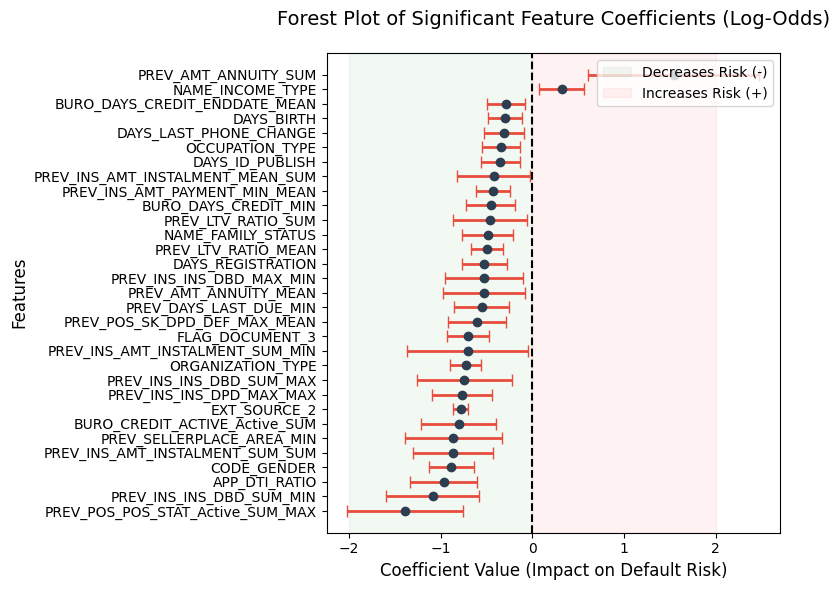

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sig_features = stats_df[stats_df['p_value'] < 0.05].sort_values(by='coef')

plt.figure(figsize=(8, 6))

plt.errorbar(x=sig_features['coef'], 
             y=sig_features.index, 
             xerr=sig_features['std_err'] * 1.96, # 95% Confidence Interval
             fmt='o', 
             color='#2c3e50', 
             ecolor='#e74c3c', 
             elinewidth=2, 
             capsize=4)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Forest Plot of Significant Feature Coefficients', fontsize=14, pad=20)
plt.xlabel('Coefficient Value (Impact on Default Risk)', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.axvspan(-2, 0, color='green', alpha=0.05, label='Decreases Risk (-)')
plt.axvspan(0, 2, color='red', alpha=0.05, label='Increases Risk (+)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## **Statistical Pruning (P-Value Selection)**

In [24]:
print(f"Initial feature count: {X_train.shape[1]}")

final_features, pruned_model = iterative_p_value_elimination(X_train, y_train, threshold=0.05)

X_train_pruned = X_train[final_features]
X_test_pruned = X_test[final_features]

Initial feature count: 96
Iteration 1: Removed 'PREV_INS_AMT_INSTALMENT_MEAN_MIN' with P-Value: 0.9581
Iteration 2: Removed 'PREV_INS_AMT_PAYMENT_SUM_MAX' with P-Value: 0.9426
Iteration 3: Removed 'PREV_AMT_APPLICATION_SUM' with P-Value: 0.9410
Iteration 4: Removed 'REG_CITY_NOT_WORK_CITY' with P-Value: 0.8946
Iteration 5: Removed 'BURO_CREDIT_TYPE_Credit card_MEAN' with P-Value: 0.8797
Iteration 6: Removed 'REGION_POPULATION_RELATIVE' with P-Value: 0.8263
Iteration 7: Removed 'PREV_AMT_ANNUITY_MAX' with P-Value: 0.8265
Iteration 8: Removed 'PREV_POS_CNT_INSTALMENT_MAX_MIN' with P-Value: 0.8210
Iteration 9: Removed 'AMT_INCOME_TOTAL' with P-Value: 0.8144
Iteration 10: Removed 'PREV_POS_POS_STAT_Active_MEAN_MIN' with P-Value: 0.8061
Iteration 11: Removed 'PREV_AMT_APPLICATION_MEAN' with P-Value: 0.7587
Iteration 12: Removed 'PREV_INS_NUM_INSTALMENT_VERSION_NUNIQUE_MEAN' with P-Value: 0.7462
Iteration 13: Removed 'PREV_POS_CNT_INSTALMENT_LAST_MEAN' with P-Value: 0.7316
Iteration 14: Remo

In [25]:
print("\n" + "="*50)
print(pruned_model.summary())
print("="*50)


                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                32599
Model:                          Logit   Df Residuals:                    32557
Method:                           MLE   Df Model:                           41
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1243
Time:                        18:53:44   Log-Likelihood:                -8009.5
converged:                       True   LL-Null:                       -9146.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -2.5608      0.032    -81.280      0.000      -2.623      -2.499
EXT_SOURCE_2                              -0.7

In [26]:
y_prob_train_pruned = pruned_model.predict(sm.add_constant(X_train_pruned))

pruned_gini = calculate_gini(y_train, y_prob_train_pruned)
pruned_ks = calculate_ks(y_train, y_prob_train_pruned)

print(f"Features      : 96 -> {len(final_features)}")
print(f"Baseline Gini : {baseline_gini:.4f} -> Pruned Gini: {pruned_gini:.4f}")
print(f"Baseline KS   : {baseline_ks:.4f} -> Pruned KS  : {pruned_ks:.4f}")

Features      : 96 -> 41
Baseline Gini : 0.5235 -> Pruned Gini: 0.5163
Baseline KS   : 0.3878 -> Pruned KS  : 0.3865


In [27]:
stats_pruned = pd.DataFrame({
    'coef': pruned_model.params,
    'std_err': pruned_model.bse,
    'z_score': pruned_model.tvalues,
    'p_value': pruned_model.pvalues,
    'ci_lower': pruned_model.conf_int()[0],
    'ci_upper': pruned_model.conf_int()[1]
}).drop('const')

stats_pruned['odds_ratio'] = np.exp(stats_pruned['coef'])

In [28]:
# 1. P-Value Clustering (The purity check)
sig_count = (stats_pruned['p_value'] < 0.05).sum()
insig_count = (stats_pruned['p_value'] >= 0.05).sum()
print(f"P-VALUE CLUSTERING:")
print(f"Significant (P < 0.05): {sig_count} (Expected: All of them)")
print(f"Insignificant (P >= 0.05): {insig_count} (Expected: 0)")

P-VALUE CLUSTERING:
Significant (P < 0.05): 41 (Expected: All of them)
Insignificant (P >= 0.05): 0 (Expected: 0)


In [29]:
# 2. Coefficient Direction (Business Logic Preview)
pos_coef = (stats_pruned['coef'] > 0).sum()
neg_coef = (stats_pruned['coef'] < 0).sum()
print(f"COEFFICIENT DIRECTION:")
print(f"Positive (+) [Increases Risk]: {pos_coef}")
print(f"Negative (-) [Decreases Risk]: {neg_coef}")

COEFFICIENT DIRECTION:
Positive (+) [Increases Risk]: 2
Negative (-) [Decreases Risk]: 39


In [30]:
# 3. Standard Error Spread (Model Confidence Check)
print(f"STANDARD ERROR SPREAD:")
print(f"Min Error: {stats_pruned['std_err'].min():.4f}")
print(f"Max Error: {stats_pruned['std_err'].max():.4f}")
print(f"Mean Error: {stats_pruned['std_err'].mean():.4f}")

STANDARD ERROR SPREAD:
Min Error: 0.0408
Max Error: 0.3715
Mean Error: 0.1631


In [31]:
# 4. Confidence Interval
crosses_zero = ((stats_pruned['ci_lower'] < 0) & (stats_pruned['ci_upper'] > 0)).sum()
print(f"CONFIDENCE INTERVAL:")
print(f"Features crossing zero: {crosses_zero} (Expected: 0)")

CONFIDENCE INTERVAL:
Features crossing zero: 0 (Expected: 0)


In [32]:
print("\n--- TOP 30 MOST POWERFUL FEATURES---")
top_powerful = stats_pruned.copy()
top_powerful['abs_z'] = top_powerful['z_score'].abs()
print(top_powerful.sort_values(by='abs_z', ascending=False)[['coef', 'odds_ratio', 'p_value', 'z_score']].head(30))


--- TOP 30 MOST POWERFUL FEATURES---
                                            coef  odds_ratio       p_value  \
EXT_SOURCE_2                           -0.787234    0.455102  8.095320e-83   
BURO_CREDIT_ACTIVE_Active_SUM          -1.114955    0.327930  3.390674e-22   
ORGANIZATION_TYPE                      -0.733381    0.480282  5.682982e-18   
CODE_GENDER                            -0.881030    0.414356  6.944704e-13   
PREV_LTV_RATIO_MEAN                    -0.535573    0.585334  3.370063e-10   
FLAG_DOCUMENT_3                        -0.708114    0.492572  1.084076e-09   
PREV_POS_POS_STAT_Active_SUM_MAX       -1.505965    0.221803  4.398727e-08   
PREV_INS_INS_DPD_MAX_MAX               -0.816539    0.441959  5.632820e-08   
PREV_INS_AMT_PAYMENT_MIN_MEAN          -0.464781    0.628273  1.057934e-07   
APP_DTI_RATIO                          -0.970644    0.378839  1.574380e-07   
PREV_POS_CNT_INSTALMENT_FUTURE_MIN_MAX -0.975009    0.377189  1.224567e-06   
PREV_DAYS_LAST_DUE_MIN    

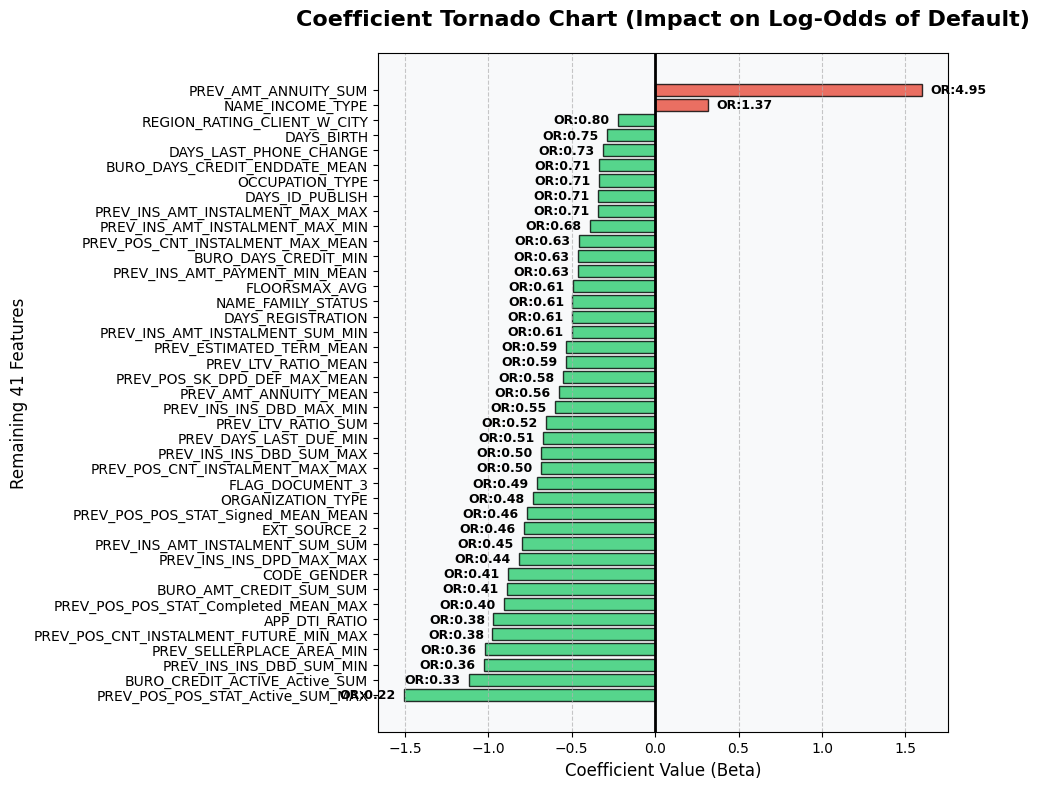

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = stats_pruned.sort_values(by='coef')

plt.figure(figsize=(10, 8))

# Color coding: Red for positive (Risk Increasing), Green for negative (Risk Decreasing)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in plot_data['coef']]

bars = plt.barh(plot_data.index, plot_data['coef'], color=colors, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)

plt.title('Coefficient Tornado Chart (Impact on Log-Odds of Default)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coefficient Value (Beta)', fontsize=12)
plt.ylabel('Remaining 41 Features', fontsize=12)

for i, bar in enumerate(bars):
    val = bar.get_width()
    or_val = plot_data['odds_ratio'].iloc[i]
    text_x = val + 0.05 if val > 0 else val - 0.05
    ha = 'left' if val > 0 else 'right'
    plt.text(text_x, bar.get_y() + bar.get_height()/2, f"OR:{or_val:.2f}", 
             va='center', ha=ha, fontsize=9, color='black', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## **Logical Consistency & Sign Check**

## **Final Model Estimation & Performance Check**

## **Scorecard Scaling (Log-Odds to Points)**

## **Artefact Exporting**